In [3]:
from astropy.io import fits
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy import units as u

# DR16Q
# fits_file = 'data/dr16q_prop_May01_2024.fits'
# hdul = fits.open(fits_file)
# data = hdul[1].data
# hdul.close()

# dr16q_coords = SkyCoord(ra=data['RA']*u.deg, dec=data['DEC']*u.deg)
# dr16q_objids = data['OBJID']


def generate_stone_lcs():
    # Load Stone et al. (2022) data
    fits_file = 'data/stone_TotalDat_v2.fits'
    hdul = fits.open(fits_file)
    data = hdul[1].data
    hdul.close()
    bands = ['g', 'r', 'i']
    fields = [
        'MAG', 'MAG_ERR', 'MJD',
        'log_SIGMA', 
        'log_TAU_REST',
    ]
    stone_lcs = {}

    for i in range(len(data)):
        dbid = data['DBID'][i]
        stone_lcs[dbid] = {
            'stone_DBID': dbid,
            'z': data['Z'][i],
            'stone_Z': data['Z'][i],
            'stone_RA': data['RA'][i],
            'stone_DEC': data['DEC'][i],
            'stone_LOG_M_BH': data['LOG_M_BH'][i],
            'stone_LOG_M_BH_ERR': data['LOG_M_BH_ERR'][i],
            'stone_LOG_LBOL': data['LOG_LBOL'][i],
            'stone_LOG_LBOL_ERR': data['LOG_LBOL_ERR'][i],        
            'mags': {},
            'magerrs': {},
            'times': {},
        }
        for band in bands:
            # Mask NaNs for MJD, MAG, and MAG_ERR fields
            mjd = data[f'MJD_{band}'][i]
            mag = data[f'MAG_{band}'][i]
            mag_err = data[f'MAG_ERR_{band}'][i]
            mask = ~np.isnan(mjd) & ~np.isnan(mag) & ~np.isnan(mag_err)

            stone_lcs[dbid]['mags'][band] = mag[mask]
            stone_lcs[dbid]['magerrs'][band] = mag_err[mask]
            stone_lcs[dbid]['times'][band] = mjd[mask]

            stone_lcs[dbid] |= {
                # f'MJD_{band}': mjd[mask],
                # f'MAG_{band}': mag[mask],
                # f'MAG_{band}_ERR': mag_err[mask],

                f'stone_log_SIGMA_{band}': data[f'log_SIGMA_{band}'][i],
                f'stone_log_SIGMA_{band}_ERR_L': data[f'log_SIGMA_{band}_ERR_L'][i],
                f'stone_log_SIGMA_{band}_ERR_U': data[f'log_SIGMA_{band}_ERR_U'][i],
                f'stone_log_TAU_REST_{band}': data[f'log_TAU_REST_{band}'][i],
                f'stone_log_TAU_REST_{band}_ERR_L': data[f'log_TAU_REST_{band}_ERR_L'][i],
                f'stone_log_TAU_REST_{band}_ERR_U': data[f'log_TAU_REST_{band}_ERR_U'][i],
                f'stone_log_SIGMA_{band}_ERR': (data[f'log_SIGMA_{band}_ERR_L'][i] + data[f'log_SIGMA_{band}_ERR_U'][i]) / 2,
                f'stone_log_TAU_REST_{band}_ERR': (data[f'log_TAU_REST_{band}_ERR_L'][i] + data[f'log_TAU_REST_{band}_ERR_U'][i]) / 2,
            }

    # stone_coords = SkyCoord(ra=data['RA']*u.deg, dec=data['DEC']*u.deg)
    # stone_ids = data['DBID']

    # # S82 Catalog
    # cat = pd.read_parquet("data/S82/Catalog.parquet").reset_index()
    # cat_coords = SkyCoord(ra=cat['RA'].values*u.deg, dec=cat['DEC'].values*u.deg)
    # cat_objids = cat['objectId'].values

    # # Match lcs within 1 arcsec
    # idx, d2d, _ = stone_coords.match_to_catalog_sky(cat_coords)
    # match_mask = d2d < 1 * u.arcsec

    # for i, matched in enumerate(match_mask):
    #     if matched:
    #         stone_lcs[stone_ids[i]]['object_id'] = str(int(cat_objids[idx[i]]))
    #     else:
    #         stone_lcs[stone_ids[i]]['object_id'] = None
    #         print(f"Warning: No match found for DBID {stone_ids[i]}")
    return stone_lcs

stone_lcs = generate_stone_lcs()

In [5]:
# Convert stone_lcs to pandas DataFrame, ignoring 'mags', 'magerrs', 'times'
def stone_lcs_to_df(stone_lcs):
    records = []
    for obj in stone_lcs.values():
        rec = {k: v for k, v in obj.items() if k not in ['mags', 'magerrs', 'times']}
        records.append(rec)
    return pd.DataFrame(records)

stone_df = stone_lcs_to_df(stone_lcs)
#stone_df['object_id'] = stone_df['object_id'].astype(str)

# Resample stone_df to match the length of symmetric_err
resampled_df = stone_df.sample(n=len(stone_df), random_state=42).reset_index(drop=True)

# Write to CSV
resampled_df.to_csv('data/oct5_stone_lcs.csv', index=False)

In [83]:
from hubble_utils import match_radec, read_quasars_from_hdf5, load_agn_data

# prefix = "oct3o_stone_b_preview_stonelcs_spl_sigma1_nofhost_fhost0_lmc-6_N1w1000s200t14co4ch4"
# quasar_list = read_quasars_from_hdf5(f"results/data/{prefix}.h5")
# df_agn = pd.DataFrame(quasar_list)
# df_agn['object_id'] = df_agn['object_id'].astype(str)


agn_df = load_agn_data("results/data/oct3j_stoneyu_nopoly_noblr_preview_stoneyu_spl_sigma1_nofhost_fhost0_lmc-6_N1w1000s200t14co4ch4.h5", populate_sdss=False, apply_cut=False, only_load=True)
agn_df['object_id'] = agn_df['object_id'].astype(str)
#df_agn = agn_df[['ra', 'dec', 'object_id']]

Reading quasars from HDF5: 100%|██████████| 189/189 [00:01<00:00, 128.45it/s]


Number of quasars loaded: 189


In [84]:
def match_radec(df_a, df_b, populate_cols=[], ra_col_a='ra', dec_col_a='dec', ra_col_b='ra', dec_col_b='dec', max_sep_arcsec=1.0, add_prefix=False):
    """
    Match objects in df_a to df_b by sky coordinates within max_sep_arcsec.
    Returns a DataFrame with indices and separation for matches.
    """
    coords_a = SkyCoord(ra=df_a[ra_col_a].values * u.deg, dec=df_a[dec_col_a].values * u.deg)
    coords_b = SkyCoord(ra=df_b[ra_col_b].values * u.deg, dec=df_b[dec_col_b].values * u.deg)

    idx, d2d, _ = coords_a.match_to_catalog_sky(coords_b)
    match_mask = d2d < max_sep_arcsec * u.arcsec

    # Prepare result DataFrame
    result = df_a.copy()
    result['matched_idx_b'] = np.where(match_mask, idx, -1)
    result['matched_sep_arcsec'] = d2d.arcsec
    # Optionally, add matched object_id or similar column if present in df_b
    for col in populate_cols:
        matched_values = np.where(match_mask, df_b.iloc[idx][col].values, None)
        if add_prefix:
            result[f'matched_{col}'] = matched_values
        else:
            result[col] = matched_values

    # Print warnings for unmatched
    unmatched_object_ids = []
    for i, matched in enumerate(match_mask):
        if not matched:
            #print(f"Warning: No match found for index {i} (RA={df_a.iloc[i][ra_col_a]}, DEC={df_a.iloc[i][dec_col_a]})")
            unmatched_object_ids.append(df_a.iloc[i]['object_id'])
    return result, unmatched_object_ids

In [85]:
cols = ['stone_DBID']
for b in ['g', 'r', 'i']:
    cols.append(f'stone_log_SIGMA_{b}')
    cols.append(f'stone_log_TAU_REST_{b}')

df, unmatched_ids = match_radec(agn_df, stone_df, populate_cols=cols, ra_col_a='ra', dec_col_a='dec', ra_col_b='stone_RA', dec_col_b='stone_DEC', max_sep_arcsec=1.0)
unmatched_ids

[]

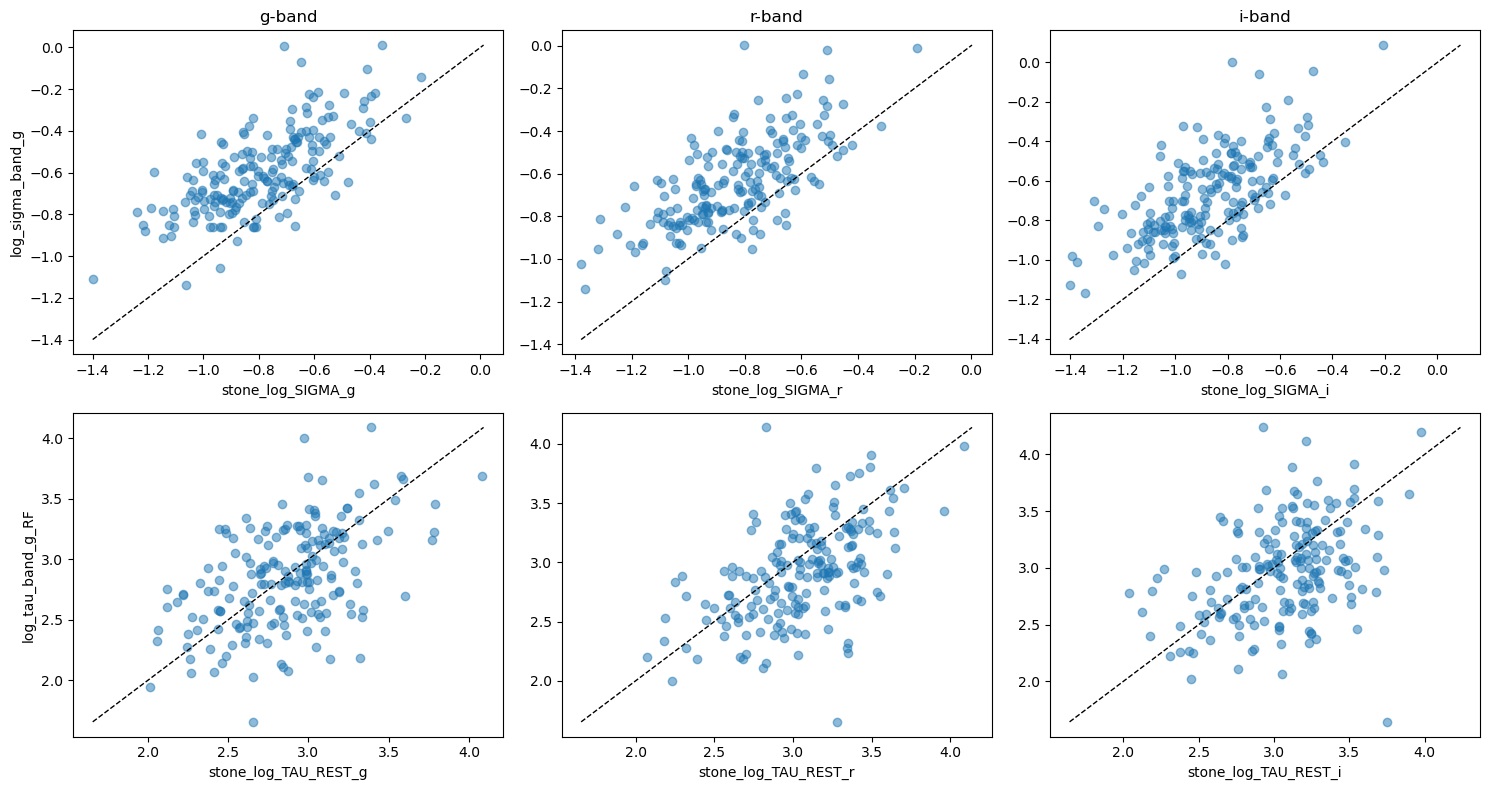

In [86]:
import matplotlib.pyplot as plt

bands = ['g', 'r', 'i']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, band in enumerate(bands):
    # Top row: stone_log_SIGMA_{band} vs log_sigma_band_{band}
    ax = axes[0, i]
    x = df[f'stone_log_SIGMA_{band}']
    y = df[f'log_sigma_band_{band}']
    ax.scatter(x, y, alpha=0.5)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    ax.set_xlabel(f'stone_log_SIGMA_{band}')
    if i == 0:
        ax.set_ylabel(f'log_sigma_band_{band}')
    ax.set_title(f'{band}-band')

    # Bottom row: stone_log_TAU_REST_{band} vs log_tau_band_{band}_RF
    ax = axes[1, i]
    x = df[f'stone_log_TAU_REST_{band}']
    y = df[f'log_tau_band_{band}_RF']
    ax.scatter(x, y, alpha=0.5)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    ax.set_xlabel(f'stone_log_TAU_REST_{band}')
    if i == 0:
        ax.set_ylabel(f'log_tau_band_{band}_RF')

plt.tight_layout()
plt.show()